In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import numpy as np
import torch
import gradio as gr
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, pipeline
from datasets import Dataset

#reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [ ]:
!git clone https://github.com/JihadZa/IADD.git

Cloning into 'IADD'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 4.86 MiB | 17.70 MiB/s, done.


In [ ]:
print(os.listdir())

['.config', 'IADD', 'sample_data']


In [ ]:
os.listdir("IADD")

['.git', 'IADD.json', 'README.md']

In [ ]:
df = pd.read_json("/content/IADD/IADD.json")

print(df.head())

                                            Sentence Region DataSource Country
0   : وش فيك تسألني إذا كنت غالي؟  غالي وتسوى من ...    GLF       DART      NA
1  روان بن حسين مستحيل ما ادز شي بسناب  حتى لو ما...    GLF       DART      NA
2   : ما نسيتك بالدعا والأرض جفاف، وشلون أبنساك و...    GLF       DART      NA
3   : فارس_البقميk_محب  أطيب من الطيب واصل الطيب ...    GLF       DART      NA
4  شوفو والله ابوها كشخه وصغير احس واضحه الفلوس م...    GLF       DART      NA


In [ ]:
df = pd.read_json("IADD/IADD.json")

print(df.head())

                                            Sentence Region DataSource Country
0   : وش فيك تسألني إذا كنت غالي؟  غالي وتسوى من ...    GLF       DART      NA
1  روان بن حسين مستحيل ما ادز شي بسناب  حتى لو ما...    GLF       DART      NA
2   : ما نسيتك بالدعا والأرض جفاف، وشلون أبنساك و...    GLF       DART      NA
3   : فارس_البقميk_محب  أطيب من الطيب واصل الطيب ...    GLF       DART      NA
4  شوفو والله ابوها كشخه وصغير احس واضحه الفلوس م...    GLF       DART      NA


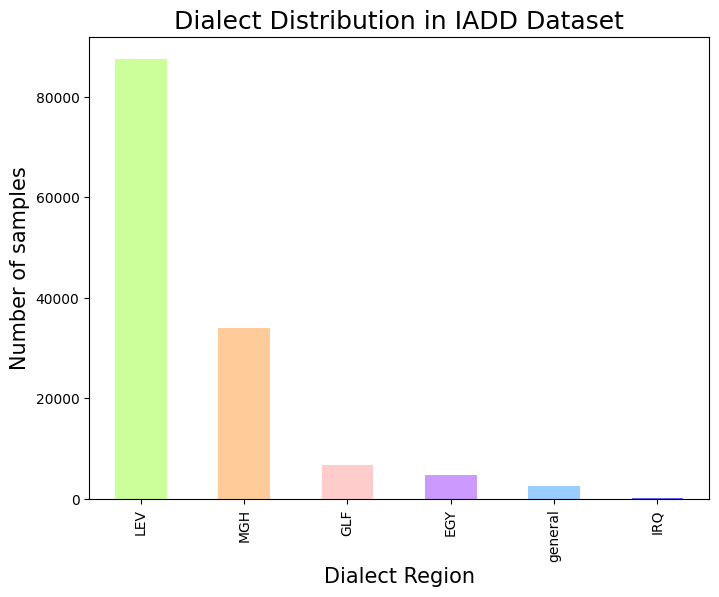

In [ ]:
plt.figure(figsize=(8, 6))
df['Region'].value_counts().plot(kind='bar',color=['#CCFF99', '#FFCC99', '#FFCCCC', '#CC99FF', '#99CCFF','#6666FF'])

plt.xlabel('Dialect Region', fontsize=15)
plt.ylabel('Number of samples', fontsize=15)
plt.title('Dialect Distribution in IADD Dataset', fontsize=18)

plt.savefig("dataset_distribution.png")
plt.show()

In [ ]:
# Preprocessing
def preprocess(text):
    text = re.sub(r'[^\u0600-\u06FF\s]', '', str(text))
    text = re.sub(r'[أإآ]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    return text

df['clean_text'] = df['Sentence'].apply(preprocess)

print(df[['Sentence', 'clean_text', 'Region']].head())

                                            Sentence  \
0   : وش فيك تسألني إذا كنت غالي؟  غالي وتسوى من ...   
1  روان بن حسين مستحيل ما ادز شي بسناب  حتى لو ما...   
2   : ما نسيتك بالدعا والأرض جفاف، وشلون أبنساك و...   
3   : فارس_البقميk_محب  أطيب من الطيب واصل الطيب ...   
4  شوفو والله ابوها كشخه وصغير احس واضحه الفلوس م...   

                                          clean_text Region  
0    وش فيك تسالني اذا كنت غالي؟  غالي وتسوي من غ...    GLF  
1  روان بن حسين مستحيل ما ادز شي بسناب  حتي لو ما...    GLF  
2    ما نسيتك بالدعا والارض جفاف، وشلون ابنساك وا...    GLF  
3    فارسالبقميمحب  اطيب من الطيب واصل الطيب طيبك...    GLF  
4  شوفو والله ابوها كشخه وصغير احس واضحه الفلوس م...    GLF  


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['Region'],
    test_size=0.2,
    random_state=42,
    stratify=df['Region']
)

print(f"\nTraining Size: {len(X_train)}")
print(f"Testing Size: {len(X_test)}")


Training Size: 108643
Testing Size: 27161


In [ ]:
# TF-IDF + Logistic Regression
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#Train
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)

#predect
lr_preds = lr_model.predict(X_test_vec)

#output
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_preds))
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy:
0.8760723095615036

Classification Report:
              precision    recall  f1-score   support

         EGY       0.82      0.50      0.62       967
         GLF       0.71      0.42      0.53      1337
         IRQ       1.00      0.02      0.05        43
         LEV       0.89      0.95      0.92     17515
         MGH       0.86      0.89      0.88      6799
     general       0.62      0.02      0.04       500

    accuracy                           0.88     27161
   macro avg       0.82      0.47      0.50     27161
weighted avg       0.87      0.88      0.86     27161



In [ ]:
# SVM
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

svm_preds = svm_model.predict(X_test_vec)

print("SVM Accuracy:")
print(accuracy_score(y_test, svm_preds))
print("\nClassification Report:")
print(classification_report(y_test, svm_preds))

SVM Accuracy:
0.8747836972129156

Classification Report:
              precision    recall  f1-score   support

         EGY       0.73      0.52      0.61       967
         GLF       0.66      0.47      0.55      1337
         IRQ       1.00      0.02      0.05        43
         LEV       0.90      0.94      0.92     17515
         MGH       0.85      0.91      0.88      6799
     general       0.32      0.03      0.06       500

    accuracy                           0.87     27161
   macro avg       0.74      0.48      0.51     27161
weighted avg       0.86      0.87      0.86     27161



In [ ]:
# Encode labels (convert dialect names into numbers)
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['Region'])

In [ ]:
#Create Train\Test DataFrame

train_df = pd.DataFrame({'text': X_train, 'label': label_encoder.transform(y_train)})
test_df = pd.DataFrame({'text': X_test, 'label': label_encoder.transform(y_test)})


# Convert pandas DataFrame into Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Load tokenizer from AraBERT model
model_name = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Tokenization function
def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# Apply tokenization to the dataset
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Remove original text column because model only needs numeric inputs
train_dataset = train_dataset.remove_columns(['text'])
test_dataset = test_dataset.remove_columns(['text'])

# Set dataset format for Torch tensors
train_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)
test_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)

Map:   0%|          | 0/108643 [00:00<?, ? examples/s]

Map:   0%|          | 0/27161 [00:00<?, ? examples/s]

In [ ]:
# Load AraBERT model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions), "f1": f1_score(labels, predictions, average='weighted')
    }

In [ ]:
# Training configuration
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Start training the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.352911,0.308890,0.914952,0.908418
2,0.231035,0.329614,0.919480,0.915491
3,0.165473,0.362970,0.923015,0.920512


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=40743, training_loss=0.26881093880338064, metrics={'train_runtime': 9285.1694, 'train_samples_per_second': 35.102, 'train_steps_per_second': 4.388, 'total_flos': 2.143965075484723e+16, 'train_loss': 0.26881093880338064, 'epoch': 3.0})

In [ ]:
#Generate predictions on the test dataset using the trained trainer objectn
preds_output = trainer.predict(test_dataset)

bert_preds = np.argmax(preds_output.predictions, axis=1)

# Decode numeric labels back into original dialect regions (e.g., GLF, LEV, MGH)
bert_pred_labels = label_encoder.inverse_transform(bert_preds)

print("\nAraBERT Accuracy:")
print(accuracy_score(y_test, bert_pred_labels))
print("\nClassification Report:")
print(classification_report(y_test, bert_pred_labels))


AraBERT Accuracy:
0.9230146165457825

Classification Report:
              precision    recall  f1-score   support

         EGY       0.79      0.73      0.76       967
         GLF       0.75      0.72      0.73      1337
         IRQ       0.87      0.63      0.73        43
         LEV       0.94      0.97      0.95     17515
         MGH       0.96      0.94      0.95      6799
     general       0.30      0.21      0.25       500

    accuracy                           0.92     27161
   macro avg       0.77      0.70      0.73     27161
weighted avg       0.92      0.92      0.92     27161



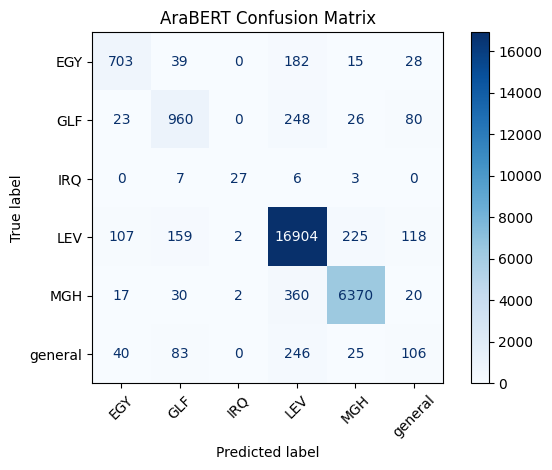

In [ ]:
# Generate and save the Confusion Matrix for AraBERT
cm = confusion_matrix(y_test, bert_pred_labels, labels=label_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# Plot and format details
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("AraBERT Confusion Matrix")
plt.tight_layout()

# Save image file locally
plt.savefig("arabert_confusion_matrix.png")
plt.show()

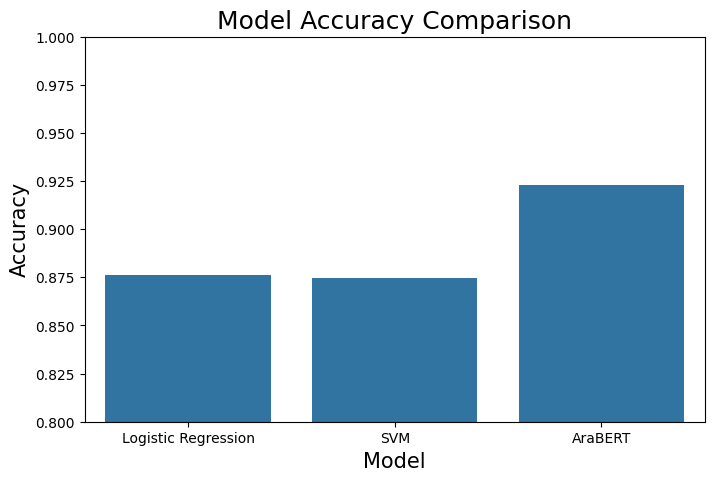

In [ ]:
#Model Comparison Graph
models = ['Logistic Regression', 'SVM', 'AraBERT']
accuracies = [accuracy_score(y_test, lr_preds), accuracy_score(y_test, svm_preds), accuracy_score(y_test, bert_pred_labels)]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies)
plt.xlabel('Model', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
plt.title('Model Accuracy Comparison', fontsize=18)
plt.ylim(0.8, 1.0)
plt.savefig("model_comparison.png")
plt.show()

In [ ]:
#prediction Function
def predict_dialect(text):

    # 1. Clean text using the identical pre-defined preprocessing function
    cleaned_text = preprocess(text)

    # 2. Tokenize the cleaned sentence input
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True, max_length=128)

    # 3. Align input tensors to the same running hardware device as the core model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 4. Turn on evaluation mode and compute model predictions
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # 5. Extract probabilities using a Softmax layer transformation
    probs = outputs.logits.softmax(dim=-1)
    pred_idx = probs.argmax(dim=-1).item()

    # 6. Retrieve string name and confidence scores
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    confidence = probs[0][pred_idx].item()

    return pred_label, confidence

# Example Prediction
sample_sentence = "وش فيك تسألني إذا كنت غالي؟"
predicted_dialect, confidence_score = predict_dialect(sample_sentence)

print(f"Input Arabic Sentence: '{sample_sentence}'")
print(f"Predicted Dialect Region: {predicted_dialect}")
print(f"Model Confidence Score: {confidence_score:.4f}")

Input Arabic Sentence: 'وش فيك تسألني إذا كنت غالي؟'
Predicted Dialect Region: GLF
Model Confidence Score: 0.9931


In [ ]:
# Define the local output storage path
output_model_dir = "./fine_tuned_arabert_dialect_id"

# Save the trained underlying PyTorch model weights and tokenizer properties
model.save_pretrained(output_model_dir)
tokenizer.save_pretrained(output_model_dir)

print(f"Fine-tuned AraBERT model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned AraBERT model saved successfully.


In [ ]:
#Gradio interface

# Dictionary mapping dialect codes to full English descriptive names for better user experience
dialect_mapping = {
    'EGY': 'Egyptian Arabic (مصر)',
    'GLF': 'Gulf Arabic (الخليج)',
    'IRQ': 'Iraqi Arabic (العراق)',
    'LEV': 'Levantine Arabic (بلاد الشام)',
    'MGH': 'Maghrebi Arabic (المغرب العربي)',
    'general': 'Modern Standard Arabic / General (الفصحى / عام)'
}

def gradio_inference(sentence):
    if not sentence.strip():
        return "Please enter a valid sentence.", 0.0

    # Reuses the predict_dialect function defined in Cell 14
    pred_label, confidence = predict_dialect(sentence)

    # Map abbreviation code to full readable name
    full_name = dialect_mapping.get(pred_label, pred_label)

    return full_name, round(confidence, 4)

# Build the Gradio Application Interface
demo = gr.Interface(
    fn=gradio_inference,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type an Arabic sentence here... / اكتب جملة بالعامية هنا",
        label="Input Arabic Sentence",
        rtl=True  # Right-to-left support for Arabic text rendering
    ),
    outputs=[
        gr.Textbox(label="Identified Dialect Region"),
        gr.Number(label="Model Confidence Score")
    ],
    title="Arabic Dialect Identification System",
    description="Type any phrase or sentence in local Arabic dialects (Egyptian, Gulf, Levantine, Maghrebi, Iraqi, or MSA) to let the fine-tuned AraBERT model classify its regional origin.",
    examples=[
        ["عامل إيه يا باشا؟ إن شاء الله كله تمام"],
        ["وش فيك زعلان مني؟ عسى ما شر يا خوي"],
        ["شو بدك تسوي اليوم بالمسار؟ شوية شوية علينا"],
        ["بزاف شباب هاد الشي، كيعجبني بزاف!"],
        ["أريد الذهاب إلى المكتبة العامة لقراءة بعض الكتب."]
    ],
    theme="soft"
)

# Launch the demo (setting share=True will generate a public link valid for 72 hours)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e6af8e3d59881c1edf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
